# Uncertainty-TTA on Kaggle / Colab — Phases 1–3

Baseline training, standard TTA, and uncertainty-weighted TTA, all driven by
the repo's `scripts/` (so results match local runs exactly).

**Kaggle data handling contributed by S2 (Mohamed Abdel Sattar).** This notebook
expects the repo to be attached as a **Kaggle Dataset** (folder
`uncertainty-tta-medmnist-main`) — the setup cell finds it under `/kaggle/input`,
copies it into the writable working dir, and clears any cached `src` imports so
code edits take effect without a kernel restart. See `docs/KAGGLE_SETUP.md`.

> All fusion math runs through `scripts.run_weighted_tta` → the repo is the single
> source of truth. Don't paste numbers from any standalone fusion notebook into the
> shared tracker; generate them here so every student's matrix row is comparable.

In [20]:
# ───────────────────────────────────────────────────────────────
# CONFIG — set this to your dataset key, then run all cells
# ───────────────────────────────────────────────────────────────
# Options: pathmnist, dermamnist, pneumoniamnist, breastmnist, bloodmnist, organamnist

DATASET    = "dermamnist"   # ← change me
EPOCHS     = 30
BATCH_SIZE = 64
LR         = 1e-4
SEED       = 42

REPO_URL    = "https://github.com/mustafaerensoyhan/uncertainty-tta-medmnist.git"
REPO_BRANCH = "main"

## 1. Verify GPU

In [21]:
import torch
print('PyTorch    :', torch.__version__)
print('CUDA avail :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU        :', torch.cuda.get_device_name(0))
else:
    print('⚠ No GPU detected. Enable it in Settings → Accelerator before continuing.')

PyTorch    : 2.10.0+cu128
CUDA avail : True
GPU        : Tesla T4


## 2. Clone the repo and install dependencies

Kaggle and Colab come with PyTorch + scikit-learn + matplotlib + pandas already installed — we only need the `medmnist` package on top.

In [22]:
# import os
# if not os.path.isdir('uncertainty-tta-medmnist'):
#     !git clone --branch {REPO_BRANCH} {REPO_URL}
# %cd uncertainty-tta-medmnist
!pip install -q medmnist==3.0.2 2>/dev/null

In [23]:
# !cp -r /kaggle/input/datasets/mohamedahmed205/phase3/uncertainty-tta-medmnist-main /kaggle/working/
# %cd /kaggle/working/uncertainty-tta-medmnist-main
# !ls

## 3. (Optional) Visual sanity check — preview 6 training samples

Confirms the data loader is working and shows you what the (normalized then denormalized) images look like for your assigned modality. Skip if you're in a hurry.

In [24]:
from pathlib import Path
import shutil
import os
import sys

# Change only this folder name
PROJECT_FOLDER_NAME = "uncertainty-tta-medmnist-main"

INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

# Find the project folder anywhere inside /kaggle/input
matches = [p for p in INPUT_ROOT.rglob(PROJECT_FOLDER_NAME) if p.is_dir()]

if not matches:
    raise FileNotFoundError(f"Could not find folder: {PROJECT_FOLDER_NAME}")

src = matches[0]
dst = WORKING_ROOT / PROJECT_FOLDER_NAME

print("Source:", src)
print("Destination:", dst)

# Remove old copied version if it exists
if dst.exists():
    shutil.rmtree(dst)

# Copy project to /kaggle/working
shutil.copytree(src, dst)

# Move into copied folder
os.chdir(dst)

# Remove old cached src imports
for m in list(sys.modules):
    if m == "src" or m.startswith("src."):
        del sys.modules[m]

# Add project root to Python path
PROJECT_DIR = str(dst)

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

print("\nCurrent directory:")
print(os.getcwd())

print("\nPython path:")
print(sys.path[:3])

print("\nProject files:")
print(os.listdir("."))
# import sys, os

# PROJECT_DIR = "/kaggle/working/uncertainty-tta-medmnist-main"

# # remove old cached src imports
# for m in list(sys.modules):
#     if m == "src" or m.startswith("src."):
#         del sys.modules[m]

# # add project root
# if PROJECT_DIR not in sys.path:
#     sys.path.insert(0, PROJECT_DIR)

# print(os.getcwd())
# print(sys.path[:3])

Source: /kaggle/input/datasets/mohamedahmed205/phase3/uncertainty-tta-medmnist-main
Destination: /kaggle/working/uncertainty-tta-medmnist-main

Current directory:
/kaggle/working/uncertainty-tta-medmnist-main

Python path:
['/kaggle/working/uncertainty-tta-medmnist-main', '/kaggle/working', '/kaggle/lib/kagglegym']

Project files:
['checkpoints', 'docs', '.github', 'scripts', 'README.md', 'tests', 'requirements.txt', 'results', 'notebooks', 'figures', 'src', '.gitignore']


100%|██████████| 100M/100M [00:04<00:00, 20.8MB/s] 


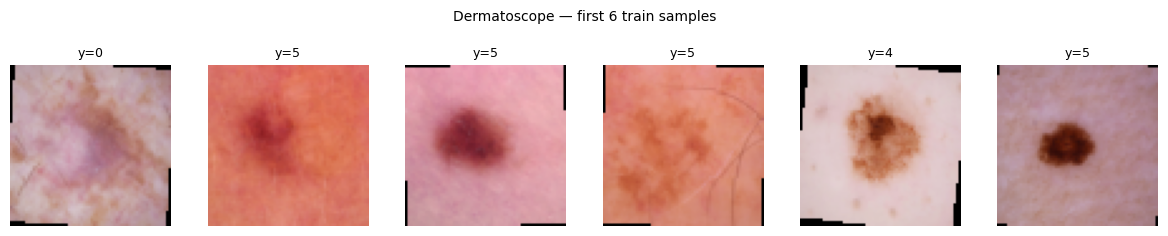

train / val / test sizes will be loaded by the script below.


In [25]:
from src.data import get_dataset
from src.config import get_config
import matplotlib.pyplot as plt

cfg = get_config(DATASET)
train_ds = get_dataset(cfg, split='train', img_size=64)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def denorm(t):
    t = t.clone()
    for c in range(3):
        t[c] = t[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    return t.clamp(0, 1)

fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for i, ax in enumerate(axes):
    img, lbl = train_ds[i]
    ax.imshow(denorm(img).permute(1, 2, 0).numpy())
    ax.set_title(f'y={int(lbl.squeeze())}', fontsize=9)
    ax.axis('off')
plt.suptitle(f'{cfg.modality} — first 6 train samples', y=1.05, fontsize=10)
plt.tight_layout(); plt.show()
print(f'train / val / test sizes will be loaded by the script below.')

## 4. Train the baseline

Calls `scripts/train_baseline.py` — the exact same entry point everyone else uses locally. First run downloads the dataset (~20–190 MB depending on which one) and the ResNet-18 ImageNet weights (~45 MB). Subsequent runs use the local cache.

The script will:
1. Download + load the dataset
2. Train ResNet-18 for 30 epochs (Adam, lr=1e-4)
3. Save the best-val checkpoint and a per-epoch training log
4. Evaluate on the test split (Accuracy, AUC, ECE, NLL)
5. Save a reliability diagram and training curves
6. Print a copy-pasteable tracker row
7. Check the result is within ±2% of the published MedMNIST benchmark

In [26]:
!python -m scripts.train_baseline \
    --dataset {DATASET} \
    --epochs {EPOCHS} \
    --batch-size {BATCH_SIZE} \
    --lr {LR} \
    --seed {SEED} \
    --num-workers 2


  Training baseline: Dermatoscope
  Dataset key       : dermamnist
  Task              : multi-class (7 classes)
  Channels (native) : 3 → converted to 3 (ImageNet)
  Owner             : S2
  Device            : cuda
  Epochs            : 30
  Batch size        : 64
  LR                : 0.0001
  Benchmark target  : 73.4% (±2% tolerance)

Loading data (this triggers download on first run)...
  train batches: 109 | val: 16 | test: 32
  ResNet-18 parameters: 11,180,103

Training for 30 epochs (best-val checkpoint saved to checkpoints/dermamnist_resnet18.pth)

  Epoch   1/30 | train_loss=0.9520 | val_loss=0.7177 | val_acc=74.88% | val_ece=0.0259  ✓ best
  Epoch   2/30 | train_loss=0.6164 | val_loss=0.6071 | val_acc=78.17% | val_ece=0.0176  ✓ best
  Epoch   3/30 | train_loss=0.5146 | val_loss=0.5779 | val_acc=80.66% | val_ece=0.0206  ✓ best
  Epoch   4/30 | train_loss=0.4496 | val_loss=0.5914 | val_acc=79.56% | val_ece=0.0656
  Epoch   5/30 | train_loss=0.3817 | val_loss=0.5933 | val_acc=

## 5. Inspect the saved metrics JSON

In [27]:
import json
with open(f'results/{DATASET}_baseline.json') as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))

{
  "dataset": "dermamnist",
  "modality": "Dermatoscope",
  "student": "S2",
  "task": "multi-class",
  "epochs": 30,
  "batch_size": 64,
  "lr": 0.0001,
  "img_size": 64,
  "checkpoint": "checkpoints/dermamnist_resnet18.pth",
  "train_log_csv": "results/dermamnist_train_log.csv",
  "reliability_figure": "figures/reliability/dermamnist_baseline.png",
  "curves_figure": "figures/curves/dermamnist_train_curves.png",
  "benchmark_acc": 0.734,
  "test_metrics": {
    "accuracy": 0.8413965087281795,
    "auc_roc": 0.9575204918668313,
    "ece": 0.09984503865539282,
    "nll": 0.7398370504379272
  },
  "training_time_minutes": 2.59
}


## 6. Show the training curves inline

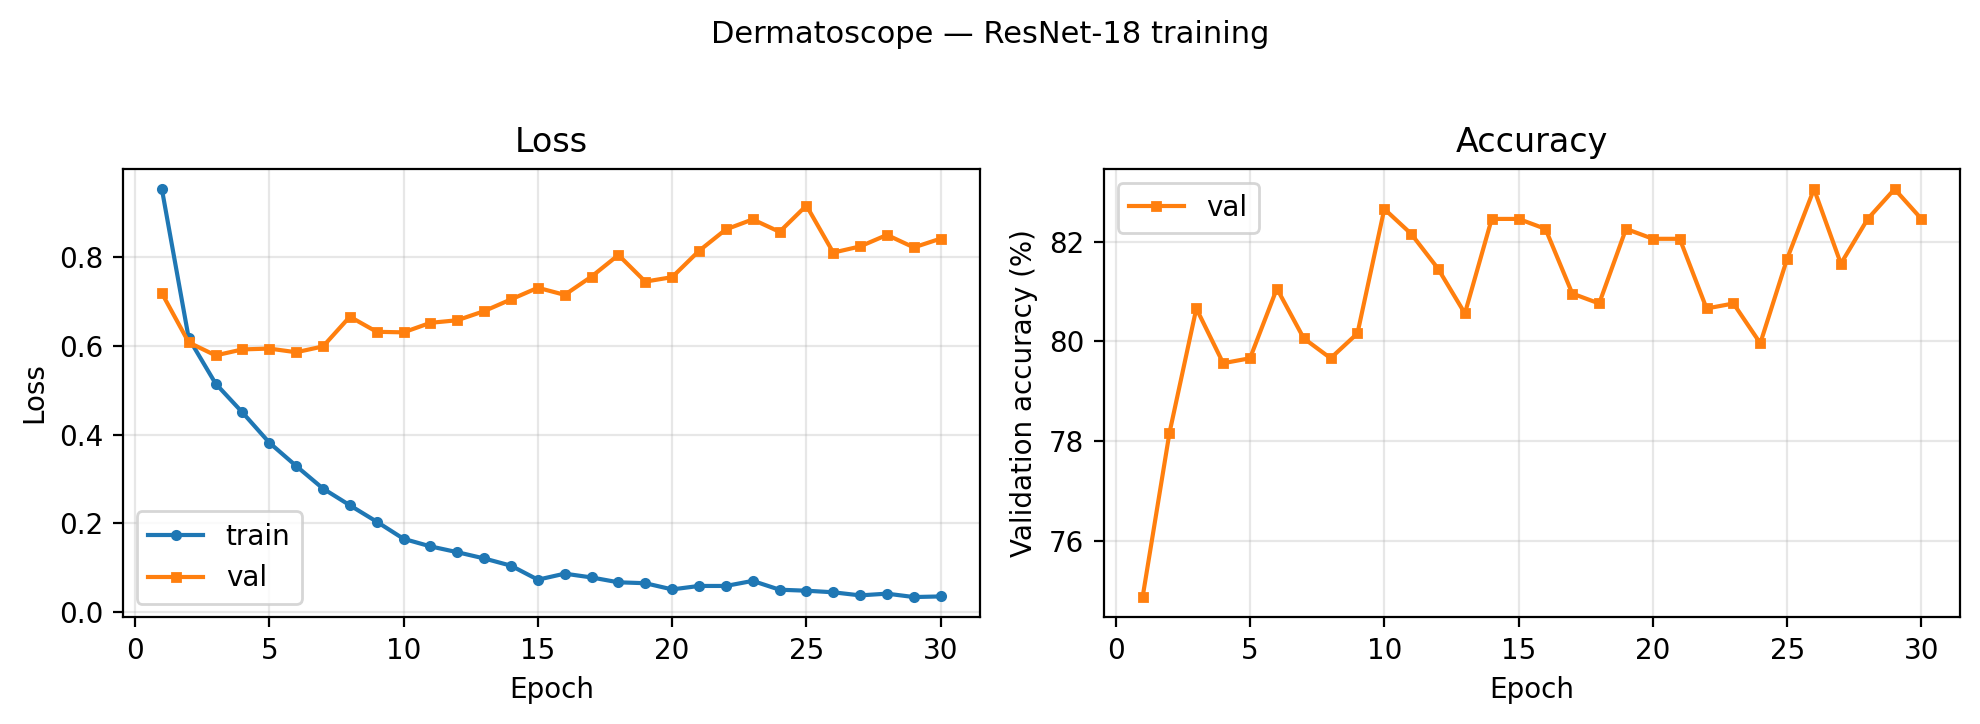

In [28]:
from IPython.display import Image, display
display(Image(filename=f'figures/curves/{DATASET}_train_curves.png'))

## 7. Show the reliability diagram inline

Points below the diagonal mean the model is **overconfident** (it says e.g. 90% but is actually right 70% of the time). Points above mean **underconfident**. A baseline should sit near the diagonal at high confidence; the TTA experiments in Phase 2/3 will measure how the curve changes.

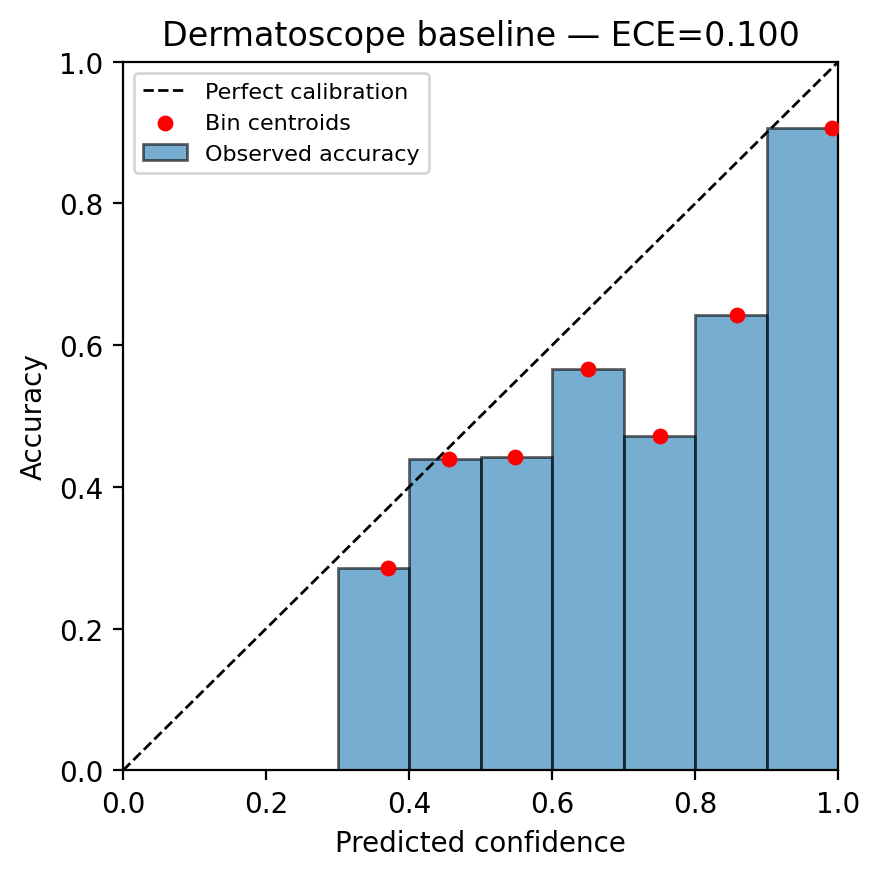

In [29]:
display(Image(filename=f'figures/reliability/{DATASET}_baseline.png'))

## 8. Optional: peek at the per-epoch training log

In [30]:
import pandas as pd
log = pd.read_csv(f'results/{DATASET}_train_log.csv')
print(log.to_string(index=False))

 epoch  train_loss  val_loss  val_acc  val_ece
     1    0.952010  0.717748 0.748754 0.025930
     2    0.616426  0.607116 0.781655 0.017627
     3    0.514577  0.577863 0.806580 0.020596
     4    0.449617  0.591373 0.795613 0.065602
     5    0.381713  0.593258 0.796610 0.059028
     6    0.329285  0.585005 0.810568 0.062557
     7    0.278412  0.598075 0.800598 0.067354
     8    0.240769  0.664975 0.796610 0.093499
     9    0.203912  0.630952 0.801595 0.089392
    10    0.165383  0.629770 0.826520 0.084591
    11    0.148391  0.651177 0.821535 0.091307
    12    0.135331  0.656979 0.814556 0.102585
    13    0.121263  0.677472 0.805583 0.103687
    14    0.104939  0.703849 0.824526 0.105780
    15    0.073429  0.730045 0.824526 0.105223
    16    0.087065  0.714065 0.822532 0.105605
    17    0.078494  0.755267 0.809571 0.116668
    18    0.067574  0.803760 0.807577 0.119646
    19    0.065559  0.743873 0.822532 0.108229
    20    0.051594  0.753912 0.820538 0.112464
    21    0.0

---

# Phase 2 — Standard TTA

The cells below run **standard equal-weight TTA** on the same dataset, reusing the checkpoint that Phase 1 just trained (it's still in `checkpoints/` from the training run above). This measures whether averaging N augmented views helps or hurts.

**Important:** these cells depend on the Phase 1 training cell (section 4) having run in this same session, because that's what created the checkpoint. If you restart the kernel, re-run sections 1–4 first.

## 9. Run standard TTA across N = 5, 10, 20, 50

In [31]:
!python -m scripts.run_standard_tta \
    --dataset {DATASET} \
    --n-views 5 10 20 50 \
    --batch-size {BATCH_SIZE} \
    --seed {SEED} \
    --num-workers 2


  Standard TTA: Dermatoscope  (dermamnist)
  Task          : multi-class (7 classes)
  Owner         : S2
  Device        : cuda
  View counts N : [5, 10, 20, 50]
  Checkpoint    : checkpoints/dermamnist_resnet18.pth

Computing N=1 no-TTA baseline (original view only)...
  baseline acc=84.14%  ece=0.0998

Running standard TTA with N=5 views...
  N= 5 | acc=84.09% (Δ -0.05pp ↓ HURTS) | ece=0.0559 | nll=0.5897 | 5.0s

Running standard TTA with N=10 views...
  N=10 | acc=84.49% (Δ +0.35pp ↑ helps) | ece=0.0623 | nll=0.5569 | 16.3s

Running standard TTA with N=20 views...
  N=20 | acc=84.69% (Δ +0.55pp ↑ helps) | ece=0.0635 | nll=0.5470 | 33.5s

Running standard TTA with N=50 views...
  N=50 | acc=84.74% (Δ +0.60pp ↑ helps) | ece=0.0589 | nll=0.5350 | 83.4s

Results saved to: results/dermamnist_standard_tta.csv
Plot saved to:    figures/tta/dermamnist_accuracy_vs_n.png

  VERDICT: standard TTA helps (or is neutral) on dermamnist.
  Best TTA acc 84.74% >= no-TTA 84.14%

Paste the rows from

## 10. Show the TTA results table

One row per N (plus the N=1 no-TTA baseline). Compare the `accuracy` column across rows — if it drops as N grows, TTA is hurting this dataset.

In [32]:
import pandas as pd
tta_df = pd.read_csv(f'results/{DATASET}_standard_tta.csv')
print(tta_df.to_string(index=False))

   dataset  n_views  accuracy  auc_roc      ece      nll
dermamnist        1  0.841397 0.957520 0.099845 0.739837
dermamnist        5  0.840898 0.959015 0.055922 0.589698
dermamnist       10  0.844888 0.962525 0.062299 0.556862
dermamnist       20  0.846883 0.962700 0.063499 0.546988
dermamnist       50  0.847382 0.962480 0.058929 0.534992


## 11. Show the Accuracy-vs-N plot inline

Blue line = accuracy, red dashed = ECE, gray dashed = no-TTA baseline. If the blue line trends below the gray line as N increases, standard TTA is degrading this dataset — exactly the finding the paper is documenting.

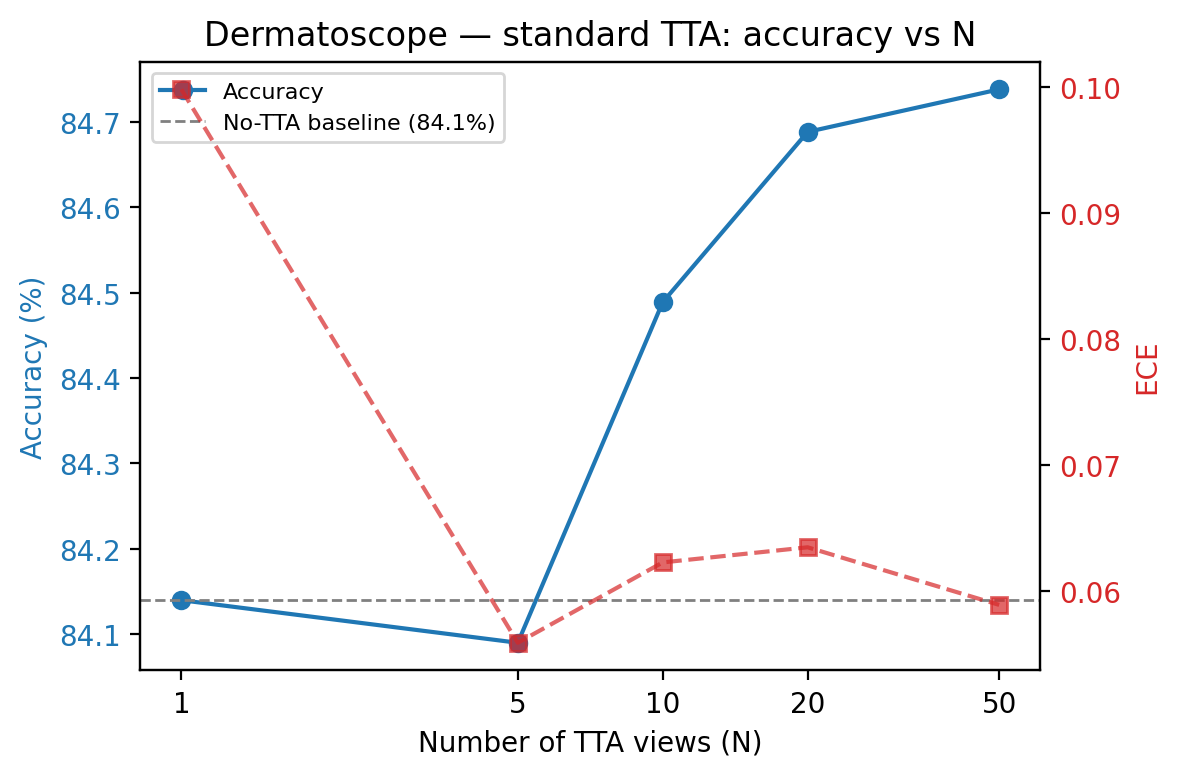

In [33]:
from IPython.display import Image, display
display(Image(filename=f'figures/tta/{DATASET}_accuracy_vs_n.png'))

---

## 12. Phase 3 — Weighted TTA: all 5 fusion strategies

Runs **baseline + max-prob + entropy + variance + MC Dropout** on your dataset and writes one row per strategy to `results/{DATASET}_weighted_tta.csv`. The four fusion strategies share a single per-view forward pass; MC Dropout runs its own T=20 stochastic passes. Requires your Phase 1 checkpoint.

In [34]:
!python -m scripts.run_weighted_tta \
    --dataset {DATASET} \
    --n-views 10 \
    --mc-T 20 --mc-p 0.2 \
    --batch-size {BATCH_SIZE} \
    --seed {SEED} \
    --num-workers 2


  Weighted TTA (Phase 3): Dermatoscope  (dermamnist)
  Task          : multi-class (7 classes)
  Owner         : S2
  Device        : cuda
  N views       : 10   |   MC Dropout: T=20, p=0.2
  Checkpoint    : checkpoints/dermamnist_resnet18.pth

Computing per-view probabilities once, then fusing 5 ways (MC Dropout runs its own passes)...

strategy                      acc%      ECE      NLL      AUC     Δacc     ΔECE
--------------------------------------------------------------------------------
Baseline TTA (w=1/N)        84.49 0.0623 0.5569 0.9625 
Max-Prob Weight (w=max p_i)  84.34 0.0701 0.5646 0.9626   -0.15  +0.0078
Entropy Weight (w=exp(-H))  84.34 0.0737 0.5707 0.9627   -0.15  +0.0114
Variance Weight (w=1/(var+e))  84.54 0.0470 0.5488 0.9621   +0.05  -0.0153
MC Dropout (T stochastic passes)  83.89 0.0979 0.7170 0.9580   -0.60  +0.0356

Results saved to: results/dermamnist_weighted_tta.csv   (2005 test images)

  Best weighted strategy on dermamnist: Variance Weight (w=1/(var+e

## 13. Show the weighted-TTA results table

Paste these five rows into **Sheet 3️⃣ Weighted TTA** of the tracker.

In [35]:
import pandas as pd
wdf = pd.read_csv(f'results/{DATASET}_weighted_tta.csv')
print(wdf.to_string(index=False))

   dataset student   strategy n_views  accuracy  auc_roc      ece      nll
dermamnist      S2   baseline      10  0.844888 0.962525 0.062299 0.556862
dermamnist      S2    maxprob      10  0.843392 0.962569 0.070085 0.564605
dermamnist      S2    entropy      10  0.843392 0.962660 0.073679 0.570672
dermamnist      S2   variance      10  0.845387 0.962067 0.046965 0.548765
dermamnist      S2 mc_dropout    T=20  0.838903 0.958045 0.097931 0.716978


## 14. Figure 1 — Augmentation Confidence Strip (§3.5, VMV)

Generated only for the four modality datasets the proposal specifies: **pathmnist, dermamnist, pneumoniamnist, bloodmnist**. Saved as a PDF for the paper; download it from the file browser (or via the Colab cell below).

In [36]:
import os
STRIP_SET = {'pathmnist','dermamnist','pneumoniamnist','bloodmnist'}
if DATASET in STRIP_SET:
    !python -m scripts.make_confidence_strips --datasets {DATASET}
    p = f'figures/strip/{DATASET}_strip.pdf'
    print('\nstrip written:', p, '| exists:', os.path.exists(p))
else:
    print(f'{DATASET} is not one of the 4 Figure-1 modalities — skipping strip.')

Generating confidence strips on cuda for: dermamnist

  [ok]   dermamnist: chosen image conf=1.000 -> figures/strip/dermamnist_strip.pdf

Done. 1/1 strips written to figures/strip.
These four strips stack into Figure 1 of the paper.

strip written: figures/strip/dermamnist_strip.pdf | exists: True


## 15. Download artifacts

In [37]:
!zip -r /kaggle/working/tta_outputs.zip checkpoints results figures
# COLAB ONLY — uncomment to download everything (Phases 1–3)
# from google.colab import files
# files.download(f'checkpoints/{DATASET}_resnet18.pth')
# files.download(f'results/{DATASET}_baseline.json')
# files.download(f'results/{DATASET}_train_log.csv')
# files.download(f'results/{DATASET}_standard_tta.csv')
# files.download(f'results/{DATASET}_weighted_tta.csv')
# files.download(f'figures/reliability/{DATASET}_baseline.png')
# files.download(f'figures/curves/{DATASET}_train_curves.png')
# files.download(f'figures/tta/{DATASET}_accuracy_vs_n.png')
# import os
# if os.path.exists(f'figures/strip/{DATASET}_strip.pdf'):
#     files.download(f'figures/strip/{DATASET}_strip.pdf')


updating: checkpoints/ (stored 0%)
updating: checkpoints/.gitkeep (stored 0%)
updating: checkpoints/dermamnist_resnet18.pth (deflated 7%)
updating: results/ (stored 0%)
updating: results/bloodmnist_baseline.json (deflated 39%)
updating: results/pathmnist_weighted_tta.csv (deflated 44%)
updating: results/dermamnist_train_log.csv (deflated 52%)
updating: results/pneumoniamnist_baseline.json (deflated 48%)
updating: results/breastmnist_baseline.json (deflated 48%)
updating: results/bloodmnist_weighted_tta.csv (deflated 48%)
updating: results/pathmnist_standard_tta.csv (deflated 47%)
updating: results/breastmnist_standard_tta.csv (deflated 49%)
updating: results/pneumoniamnist_standard_tta.csv (deflated 48%)
updating: results/organamnist_baseline.json (deflated 47%)
updating: results/pathmnist_baseline.json (deflated 38%)
updating: results/.gitkeep (stored 0%)
updating: results/dermamnist_standard_tta.csv (deflated 46%)
updating: results/bloodmnist_standard_tta.csv (deflated 48%)
updating:

---

## Next steps for the team

**Phase 1 deliverable:**
1. Paste the baseline tracker row into Sheet 1️⃣ Baselines.
2. Upload the `.pth` checkpoint to the shared Drive folder.

**Phase 2 deliverable:**
3. Paste the rows of `results/{DATASET}_standard_tta.csv` into Sheet 2️⃣ Standard TTA.
4. Note in the group chat whether TTA helped or hurt your dataset (the script prints a verdict).

**Then open a PR** with your results files. From your local clone:
```bash
git checkout -b s2-{dataset}-results   # adjust to your S-id and dataset
git add results/{dataset}_baseline.json results/{dataset}_train_log.csv results/{dataset}_standard_tta.csv
git commit -m "S2: {dataset} baseline + standard TTA results"
git push -u origin s2-{dataset}-results
```
Then open the PR on GitHub. @mustafaerensoyhan will review and merge.

**Don't commit:** the `.pth` checkpoint (gitignored, share via Drive), dataset `.npz` files (gitignored), or anything outside `results/`.